# HMC / NUTS Modeling Notebook

This notebook contains Bayesian modeling using PyMC with HMC/NUTS sampling.

## Overview

This notebook implements Bayesian logistic regression using Hamiltonian Monte Carlo (HMC) with the No-U-Turn Sampler (NUTS) to infer posterior distributions over model parameters. The implementation uses preprocessed data from the transforms notebook.

In [16]:
# Import required libraries
import sys
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import arviz as az
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import os

# Print versions for reproducibility
print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("PyMC:", pm.__version__)
print("PyTensor:", pytensor.__version__)
print("ArviZ:", az.__version__)

Python: /opt/anaconda3/envs/pymc3.11/bin/python
NumPy: 2.3.4
PyMC: 5.26.1
PyTensor: 2.35.1
ArviZ: 0.22.0


## Step 1: Load Transformed Data from 02_transforms.ipynb

Load preprocessed data that was saved from the transforms notebook.


In [17]:
# Load data from transforms_and_modelling notebook
# This matches the approach used in HMC_NUTS.ipynb
# Use allow_pickle=True in case the arrays contain object dtypes
X_trs = pd.DataFrame(np.load('../../data/processed/X_trs.npy', allow_pickle=True))
X_vas = pd.DataFrame(np.load('../../data/processed/X_vas.npy', allow_pickle=True))
y_tr = np.load('../../data/processed/y_tr.npy', allow_pickle=True)
y_va = np.load('../../data/processed/y_va.npy', allow_pickle=True)

with open('../../data/processed/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../../data/processed/cont_feats.pkl', 'rb') as f:
    cont_feats = pickle.load(f)

with open('../../data/processed/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Set column names
X_trs.columns = feature_names
X_vas.columns = feature_names

print("Data loaded for PyMC notebook")
print(f"X_trs shape: {X_trs.shape}, y_tr shape: {y_tr.shape}")
print(f"X_vas shape: {X_vas.shape}, y_va shape: {y_va.shape}")


Data loaded for PyMC notebook
X_trs shape: (9288, 66), y_tr shape: (9288,)
X_vas shape: (2322, 66), y_va shape: (2322,)


In [18]:
# Display first few rows to verify data loaded correctly
X_trs.head()


,Administrative_alr,Informational_alr,Administrative_Duration_alr,Informational_Duration_alr,PageValues,BounceRates,ExitRates,Weekend,SpecialDay,VisitorType_New_Visitor,...,TrafficType_18,TrafficType_19,TrafficType_20,OperatingSystems_1,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8
0,-1.119267,-0.555992,-1.079138,-0.523528,-0.327708,-0.526528,0.548821,0.0,0.6,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.931108,1.830943,0.902899,1.437274,-0.105550,-0.313574,-0.351355,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.119267,-0.555992,-1.079138,-0.523528,-0.327708,-0.526528,-0.127026,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.783421,-0.539721,0.554117,-0.520116,-0.327708,-0.526528,-0.636105,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-1.119267,-0.555992,-1.079138,-0.523528,-0.327708,-0.526528,-0.162135,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 2: Prepare Data for PyMC

Data is already split and scaled from the transforms notebook.


In [19]:
# Data is already split and scaled, so we can proceed directly to PyMC
# Verify data shapes
print(f"Training set: X_trs shape {X_trs.shape}, y_tr shape {y_tr.shape}")
print(f"Validation set: X_vas shape {X_vas.shape}, y_va shape {y_va.shape}")


Training set: X_trs shape (9288, 66), y_tr shape (9288,)
Validation set: X_vas shape (2322, 66), y_va shape (2322,)


## Step 3: Implement HMC-NUTS with PyMC


In [20]:
# Prepare data for PyMC
# Convert training design matrix to float64 NumPy array to avoid dtype surprises
X_array = X_trs.to_numpy(dtype=np.float64)
# Cast labels to int32 (PyMC expects ints for Bernoulli observed values)
y_array = y_tr.astype(np.int32)

print(f"Feature matrix shape: {X_array.shape}")
print(f"Target shape: {y_array.shape}")
print(f"Number of features: {X_array.shape[1]}")
print(f"X_array dtype: {X_array.dtype}, y_array dtype: {y_array.dtype}")


Feature matrix shape: (9288, 66)
Target shape: (9288,)
Number of features: 66
X_array dtype: float64, y_array dtype: int32


In [21]:
# Define Bayesian logistic regression model in PyMC
with pm.Model() as shopper_model:
    # Gaussian priors on coefficients (including intercept)
    beta = pm.Normal("beta", mu=0, sigma=2, shape=X_array.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    # Linear predictor: X @ beta + intercept
    logits = intercept + pm.math.dot(X_array, beta)

    # Bernoulli likelihood for conversion outcome
    y_obs = pm.Bernoulli("y_obs", logit_p=logits, observed=y_array)

    # Hamiltonian Monte Carlo via NUTS sampler
    trace = pm.sample(
        draws=2000,       # posterior draws after tuning
        tune=2000,        # warmup iterations for step-size adaptation
        target_accept=0.9,  # more conservative step-size to reduce divergences
        random_seed=42,
        cores=4,          # use 4 cores for parallel chains
        progressbar=True
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept]


/opt/anaconda3/envs/pymc3.11/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 42 seconds.


## Step 4: Generate Diagnostics and Metrics

Reproduce the same diagnostic metrics and validation checks as shown in HMC_NUTS.ipynb.


In [22]:
# Generate ArviZ summary statistics
summary = az.summary(trace, var_names=["beta", "intercept"])
summary["feature"] = ["intercept"] + list(X_trs.columns)
print("Summary Statistics (first 10 rows):")
print(summary[["feature", "mean", "sd", "hdi_3%", "hdi_97%"]].head(10))


Summary Statistics (first 10 rows):
                             feature   mean     sd  hdi_3%  hdi_97%
beta[0]                    intercept  0.442  0.142   0.182    0.711
beta[1]           Administrative_alr  0.237  0.089   0.068    0.405
beta[2]            Informational_alr -0.336  0.142  -0.599   -0.074
beta[3]  Administrative_Duration_alr -0.089  0.089  -0.252    0.081
beta[4]   Informational_Duration_alr  1.553  0.051   1.460    1.647
beta[5]                   PageValues -0.022  0.094  -0.204    0.148
beta[6]                  BounceRates -0.535  0.084  -0.692   -0.380
beta[7]                    ExitRates  0.133  0.081  -0.025    0.278
beta[8]                      Weekend  0.087  0.255  -0.388    0.579
beta[9]                   SpecialDay  0.117  0.098  -0.063    0.305


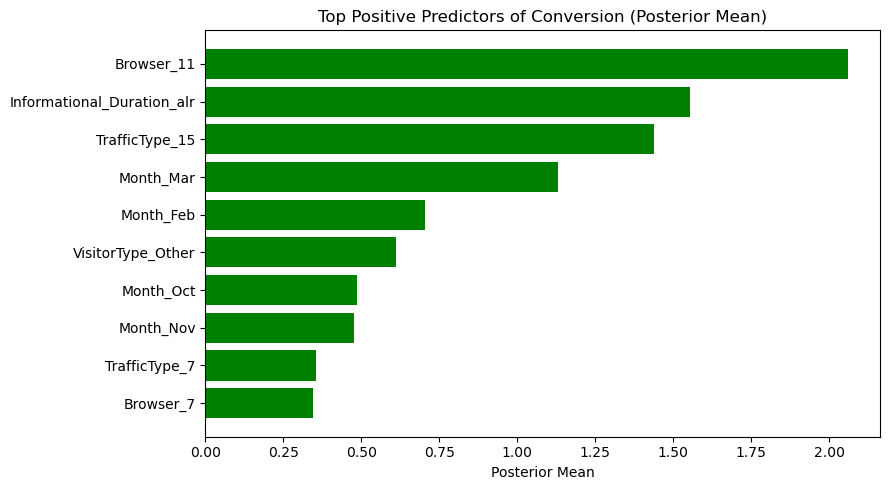

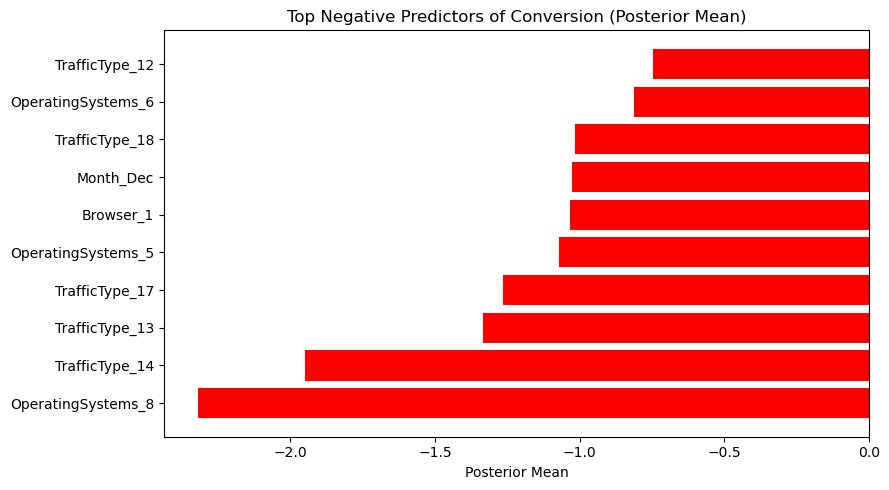

In [23]:
# Visualize top positive and negative predictors
summary_beta = summary.loc[summary["feature"] != "intercept"]
summary_sorted = summary_beta.sort_values("mean")

top_pos = summary_sorted.tail(10)
top_neg = summary_sorted.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_pos["feature"], top_pos["mean"], color="green")
plt.title("Top Positive Predictors of Conversion (Posterior Mean)")
plt.xlabel("Posterior Mean")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.barh(top_neg["feature"], top_neg["mean"], color="red")
plt.title("Top Negative Predictors of Conversion (Posterior Mean)")
plt.xlabel("Posterior Mean")
plt.tight_layout()
plt.show()


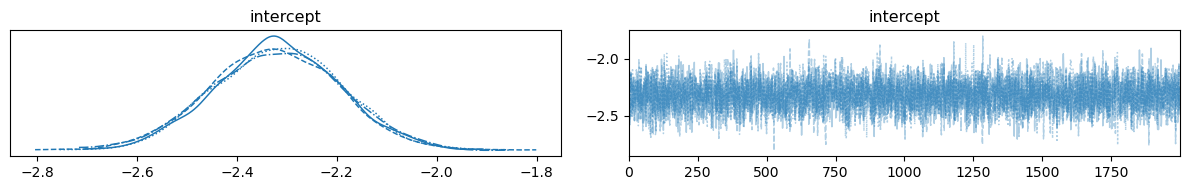

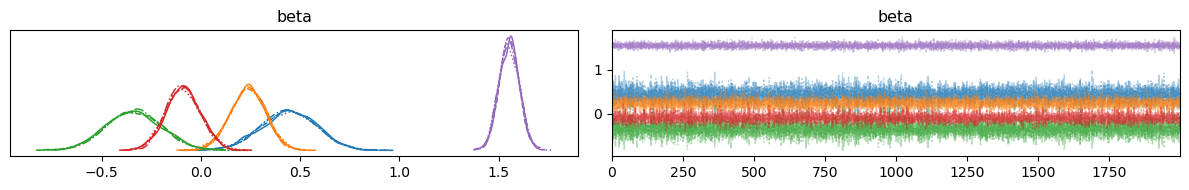

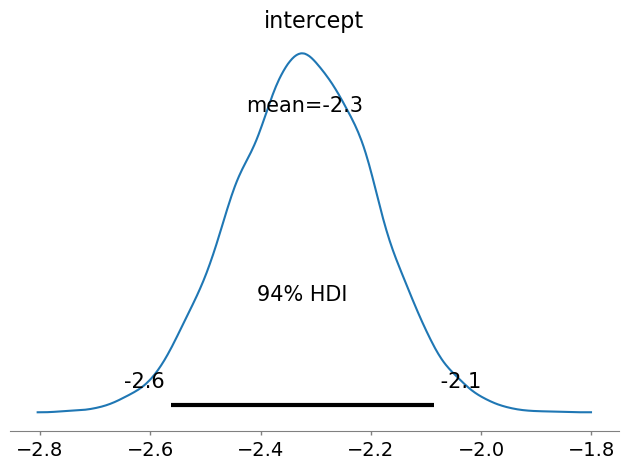

In [24]:
# Trace plots and posterior distributions
# Plot trace for intercept
az.plot_trace(trace, var_names=["intercept"])
plt.tight_layout()
plt.show()

# Plot a sample of beta coefficients (first 5) to check convergence
# In PyMC, beta is stored as a vector, so we use coords to select specific indices
# Get the dimension name for beta (usually 'beta_dim_0' or similar)
beta_dims = list(trace.posterior['beta'].dims)
beta_coord_name = [d for d in beta_dims if d != 'chain' and d != 'draw'][0]
az.plot_trace(trace, var_names=["beta"], coords={beta_coord_name: range(min(5, X_array.shape[1]))})
plt.tight_layout()
plt.show()

# Posterior distribution for intercept
az.plot_posterior(trace, var_names=["intercept"])
plt.tight_layout()
plt.show()


In [25]:
# Convergence diagnostics: R-hat and ESS
print("Convergence Diagnostics:")
print("=" * 50)

# Get R-hat values (should be < 1.01 for convergence)
rhat = az.rhat(trace)
print("\nR-hat values (should be < 1.01):")
print(f"Intercept R-hat: {rhat['intercept'].values:.4f}")
print(f"Beta R-hat range: [{rhat['beta'].values.min():.4f}, {rhat['beta'].values.max():.4f}]")
if rhat['beta'].values.max() > 1.01:
    print("WARNING: Some R-hat values > 1.01, chains may not have converged")
else:
    print("✓ All R-hat values < 1.01, chains appear converged")

# Get effective sample size
ess = az.ess(trace)
print(f"\nEffective Sample Size (ESS):")
print(f"Intercept ESS: {ess['intercept'].values:.0f}")
print(f"Beta ESS range: [{ess['beta'].values.min():.0f}, {ess['beta'].values.max():.0f}]")
print(f"Total draws: {trace.posterior.sizes['chain'] * trace.posterior.sizes['draw']}")

# Check for divergences
if hasattr(trace, 'sample_stats') and 'diverging' in trace.sample_stats:
    n_divergences = trace.sample_stats.diverging.sum().values
    print(f"\nDivergences: {n_divergences}")
    if n_divergences > 0:
        print("WARNING: Divergences detected. Consider adjusting target_accept or reparameterizing.")
    else:
        print("✓ No divergences detected")


Convergence Diagnostics:

R-hat values (should be < 1.01):
Intercept R-hat: 1.0009
Beta R-hat range: [0.9998, 1.0037]
✓ All R-hat values < 1.01, chains appear converged

Effective Sample Size (ESS):
Intercept ESS: 5942
Beta ESS range: [5766, 19506]
Total draws: 8000

Divergences: 0
✓ No divergences detected


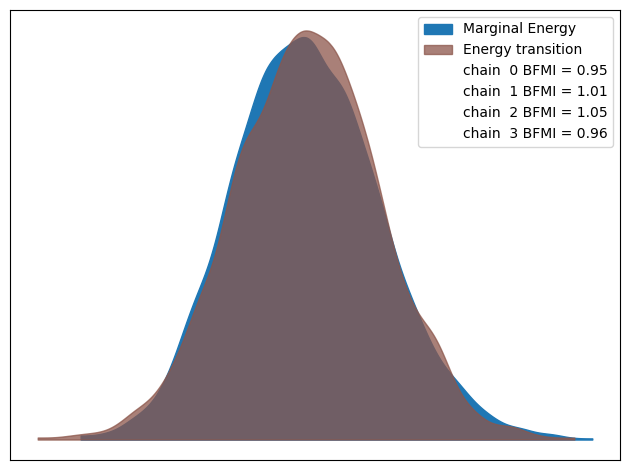

In [26]:
# Energy plot to check for sampling issues
az.plot_energy(trace)
plt.tight_layout()
plt.show()


## Step 5: Save Results

Save PyMC model results for downstream analysis (e.g., rationality estimation).


In [28]:
# Save PyMC model results
os.makedirs('../../data/processed', exist_ok=True)

# Extract posterior means and summaries
beta_posterior_mean = trace.posterior["beta"].mean(dim=["chain", "draw"]).values
intercept_posterior_mean = trace.posterior["intercept"].mean(dim=["chain", "draw"]).values
beta_posterior_std = trace.posterior["beta"].std(dim=["chain", "draw"]).values
intercept_posterior_std = trace.posterior["intercept"].std(dim=["chain", "draw"]).values

# Extract ALL actual posterior samples (all draws from all chains)
beta_all_samples = trace.posterior["beta"].values.reshape(-1, trace.posterior["beta"].shape[-1])
intercept_all_samples = trace.posterior["intercept"].values.reshape(-1)

# Save trace (full posterior samples)
with open('../../data/processed/pymc_trace.pkl', 'wb') as f:
    pickle.dump(trace, f)

# Save summary statistics
with open('../../data/processed/pymc_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

# Save posterior means, stds, AND all actual samples for easy access
pymc_results = {
    'beta_mean': beta_posterior_mean,
    'beta_std': beta_posterior_std,
    'beta_all_samples': beta_all_samples,
    'intercept_mean': intercept_posterior_mean,
    'intercept_std': intercept_posterior_std,
    'intercept_all_samples': intercept_all_samples,
    'feature_names': list(X_trs.columns),
    'n_features': X_array.shape[1],
    'n_samples': len(y_array),
    'n_chains': trace.posterior.sizes['chain'],
    'n_draws': trace.posterior.sizes['draw']
}

with open('../../data/processed/pymc_posterior_estimates.pkl', 'wb') as f:
    pickle.dump(pymc_results, f)

# Save scaler and feature names for later use
with open('../../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../../data/processed/cont_feats.pkl', 'wb') as f:
    pickle.dump(cont_feats, f)

with open('../../data/processed/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X_trs.columns), f)

# Save model for potential future use (optional)
model_saved = False
try:
    with open('../../data/processed/pymc_model.pkl', 'wb') as f:
        pickle.dump(shopper_model, f)
    model_saved = True
except Exception as e:
    print(f"Warning: Could not save model object: {type(e).__name__}: {e}")
    print("  (This is okay - you can recreate the model using saved parameters if needed)")

print("\nPyMC results saved successfully!")
print(f"Beta posterior mean shape: {beta_posterior_mean.shape}")
print(f"Beta ALL samples shape: {beta_all_samples.shape} (all draws from all chains)")
print(f"Intercept ALL samples shape: {intercept_all_samples.shape}")
print(f"Intercept posterior mean: {intercept_posterior_mean:.4f}")
print(f"Beta posterior mean range: [{beta_posterior_mean.min():.4f}, {beta_posterior_mean.max():.4f}]")
print(f"\nSaved files:")
print("  - pymc_trace.pkl (full trace with all posterior samples)")
print("  - pymc_summary.pkl (ArviZ summary statistics)")
print("  - pymc_posterior_estimates.pkl (posterior means/stds + ALL actual samples + metadata)")
print("  - scaler.pkl (StandardScaler for continuous features)")
print("  - cont_feats.pkl (list of continuous feature names)")
print("  - feature_names.pkl (list of all feature names)")
if model_saved:
    print("  - pymc_model.pkl (PyMC model object)")


  (This is okay - you can recreate the model using saved parameters if needed)

PyMC results saved successfully!
Beta posterior mean shape: (66,)
Beta ALL samples shape: (8000, 66) (all draws from all chains)
Intercept ALL samples shape: (8000,)
Intercept posterior mean: -2.3205
Beta posterior mean range: [-1.9484, 2.0598]

Saved files:
  - pymc_trace.pkl (full trace with all posterior samples)
  - pymc_summary.pkl (ArviZ summary statistics)
  - pymc_posterior_estimates.pkl (posterior means/stds + ALL actual samples + metadata)
  - scaler.pkl (StandardScaler for continuous features)
  - cont_feats.pkl (list of continuous feature names)
  - feature_names.pkl (list of all feature names)
